# Test Nicos Parameter

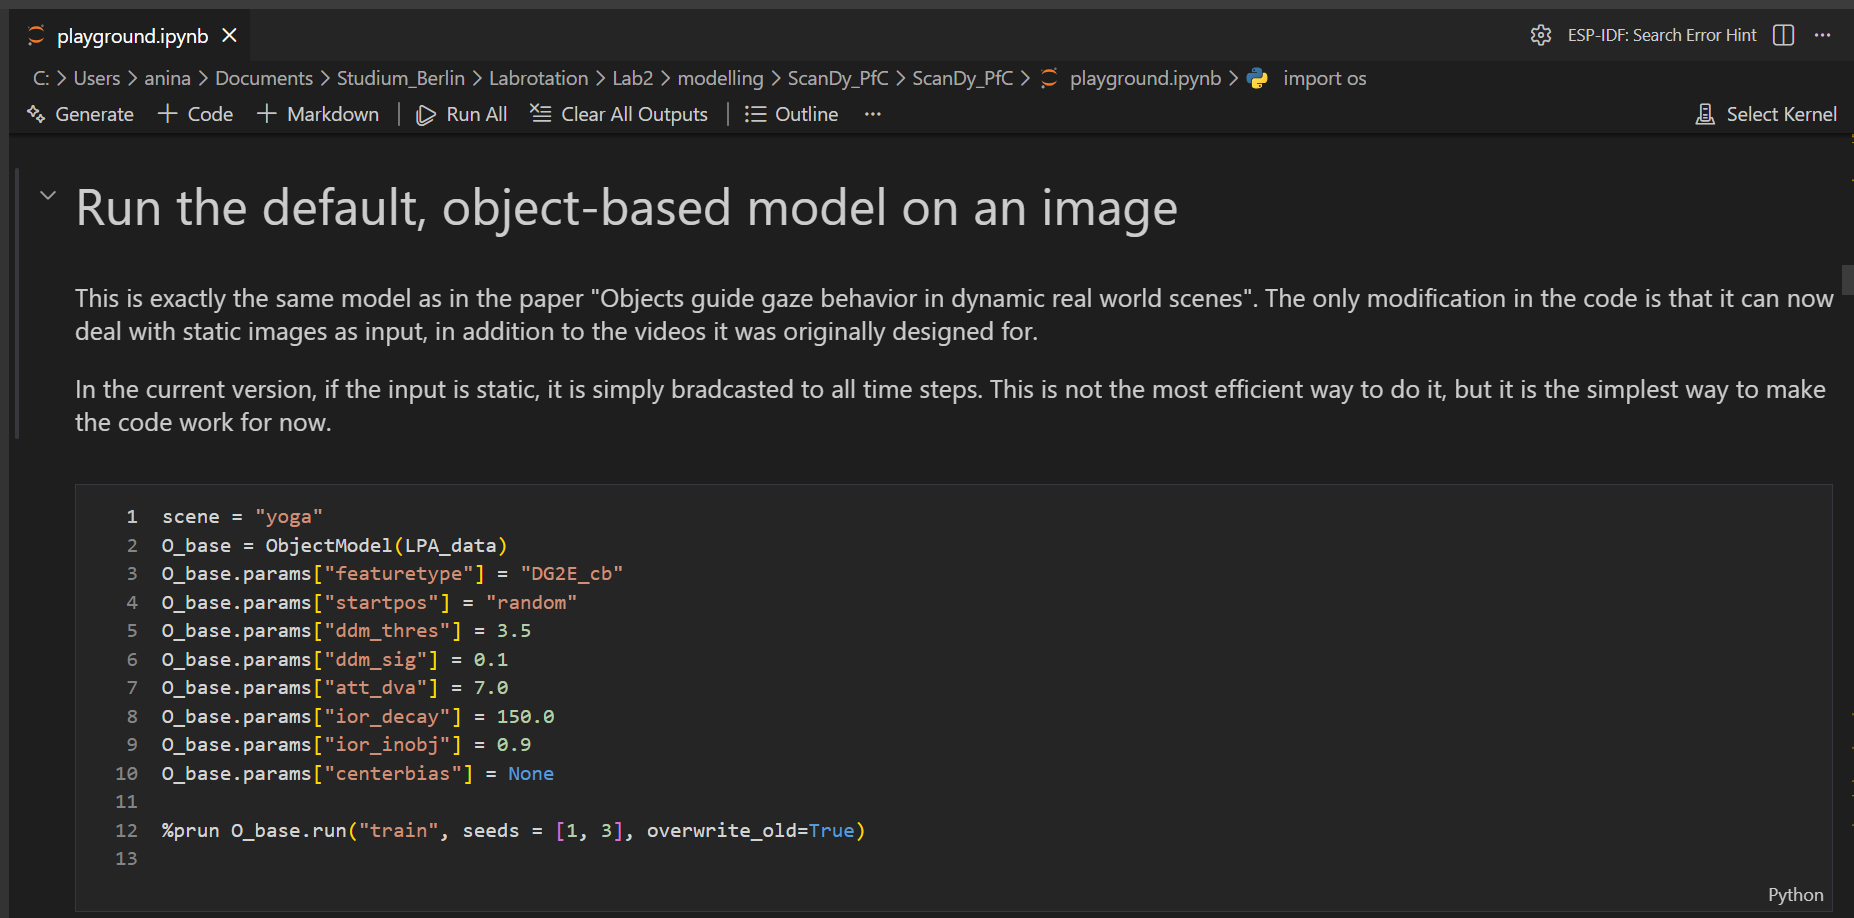

Parameter from Nicos Notebook: playground.py 

In [ ]:
# change to the root directory of the project
from pathlib import Path
import os

cwd = Path.cwd()
#or set manual: 
#cwd = '.../ScanDy'

for parent in [cwd] + list(cwd.parents):
    if (parent / "data").exists():
        os.chdir(parent)
        break

print(Path.cwd())


In [ ]:
import numpy as np
import pandas as pd
import random
import seaborn as sns
import matplotlib.pyplot as plt
import importlib
import scandy_pfc.models.model as base_model 
import scandy_pfc.models.ObjectModel as objectmodel_module
import scandy_pfc.utils.dataclass as dataclass_module
import scandy_pfc.utils.functions as uf

from neurolib.utils.parameterSpace import ParameterSpace
from neurolib.optimize.evolution import Evolution

from IPython import display

import pickle
import os
from matplotlib.legend_handler import HandlerTuple

In [ ]:
importlib.reload(dataclass_module)
Dataset = dataclass_module.Dataset
importlib.reload(base_model)
importlib.reload(objectmodel_module)
ObjectModel = objectmodel_module.ObjectModel


dircl = ['xkcd:maroon', sns.color_palette("Dark2")[1], sns.color_palette("Dark2")[5], sns.color_palette("Dark2")[6] ]



In [ ]:
datadict = {
    "PATH": "PictureExample/",  #For faster processing during testing, resize the videos to smaller dimensions
    'FPS' : 30,
    'PX_TO_DVA' : ((47.7 * 0.8) / 1920), #For faster processing during testing, resize the videos to smaller dimensions
    'FRAMES_ALL_VIDS' : 150,
    'VID_EXTENSION' : 'png',
    'dataformat' : 'picture',
    'NAME_COL' : 'scene', 
    'gt_foveation_df' : 'parkinson_data/df_all_fovs_psycsci.csv',
    "outputpath" : os.getcwd()+"/visualizations/" 
}
VidCom = Dataset(datadict)


In [ ]:
# Initialize model
model = ObjectModel(VidCom)
#parameters see playground.ipynb for reference
model.params["ddm_thres"] = 3.5      
model.params["ddm_sig"] = 0.1        
model.params["att_dva"] = 7.0         
model.params["ior_decay"] = 150.0      
model.params["ior_inobj"] = 0.9       
model.params["featuretype"] = "DG2E_cb"
model.params["centerbias"] = None
model.params["startpos"] = "random"

rang = 0
filename = f"results/nicos_params/best_hl_nico_{rang}.pkl"
df_filename = f"results/nicos_params/best_hl_nico_{rang}.csv.gz"





In [ ]:
#list1 from paper example objects
list1 = ['conversation', 'watering', 'crowBall', 'axolotl', 'catcafe', 'phone', 'ballBalance', 'trafficLight2', 'toaster', 'trinkvogel2']
#list2 filled up with 10 more objects to have 20 in total, as in paper
list2 = [
    'conversation', 'watering', 'crowBall', 'axolotl', 'catcafe',
    'phone', 'ballBalance', 'trafficLight2', 'toaster', 'trinkvogel2',
    'fingerTapping', 'statues', 'work2', 'pedestrian', 'fish',
    'chessBoard', 'youtube', 'lizard', 'coffeeOnSofa', 'reindeers'
]
model.Dataset.used_videos = list2
len(model.Dataset.used_videos)

In [ ]:
# Run the model simulation

model.run('all', seeds=[s for s in range(1, 10)], overwrite_old=True)


In [ ]:

# Save pickle file
with open(filename, 'wb') as file:
    pickle.dump(model.result_dict, file)

# Save CSV file 
if os.path.isfile(df_filename) == False:
    model.evaluate_all_to_df()
    model.result_df.to_csv(df_filename, compression="gzip", index=False)

In [ ]:
filename = f"results/nicos_params/best_hl_nico_0.pkl"
df_filename = f"results/nicos_params/best_hl_nico_0.csv"
# Save pickle file
with open(filename, 'wb') as file:
    pickle.dump(model.result_dict, file)

# Save CSV file 
if os.path.isfile(df_filename) == False:
    model.evaluate_all_to_df()
    model.result_df.to_csv(df_filename, compression="gzip", index=False)

In [ ]:
simulate_file = 'results/nicos_params/best_hl_nico_0.csv.gz'
if os.path.exists(simulate_file):
    print(f"\nLoading simulated data from: {simulate_file}")
    sim_df = pd.read_csv(simulate_file, compression='gzip')
    
    sim_amp_dva = sim_df["sac_amp_dva"].dropna().values
    sim_dur_ms = sim_df["duration_ms"].dropna().values
    
    print(f"Simulated saccade amplitudes: n={len(sim_amp_dva)}, mean={sim_amp_dva.mean():.2f}, median={np.median(sim_amp_dva):.2f}")
    print(f"Simulated durations: n={len(sim_dur_ms)}, mean={sim_dur_ms.mean():.2f}, median={np.median(sim_dur_ms):.2f}")


In [ ]:
def get_BDIR_per_frames(df, fps=30):
    """Calculate BDIR ratios per frame."""
    cat_col = 'fov_category' if 'fov_category' in df.columns else 'fov_cat'
    start_col = 'frame_start' if 'frame_start' in df.columns else 't_start'
    end_col = 'frame_end' if 'frame_end' in df.columns else 't_end'
    
    use_ms = start_col == 't_start'
    
    if use_ms:
        max_frame = int(df[end_col].max() / 1000 * fps) + 1
    else:
        max_frame = int(df[end_col].max()) + 1
    
    BDIR_per_frames = np.zeros((4, max_frame))
    bdir_to_row = {'B': 0, 'D': 1, 'I': 2, 'R': 3}
    
    for index, row in df.iterrows():
        if use_ms:
            frame_start = int(row[start_col] / 1000 * fps)
            frame_end = int(row[end_col] / 1000 * fps)
        else:
            frame_start = int(row[start_col])
            frame_end = int(row[end_col])
        
        frame_start = max(0, min(frame_start, max_frame - 1))
        frame_end = max(0, min(frame_end, max_frame - 1))
        
        BDIR_per_frames[bdir_to_row[row[cat_col]], frame_start:frame_end + 1] += 1
    
    denominator = np.sum(BDIR_per_frames, axis=0)
    denominator[denominator == 0] = 1
    BDIR_ratios_per_frames = 100 * BDIR_per_frames / denominator
    
    return BDIR_ratios_per_frames

def plot_bdir_timecourse(VidCom, run_ids, groups, zoom_frames=60):
    """Plot BDIR categories over time for all groups."""
    dirnames = ['Background', 'Detection', 'Inspection', 'Revisit']
    n_keys = len(groups)
    n_cols = 4  # Human Full, Human Zoom, Model Full, Model Zoom
    n_rows = n_keys  # One row per group
    
    fig, axs = plt.subplots(n_rows, n_cols, dpi=200, figsize=(20, 4 * n_keys), sharex=False, sharey=True)
    
    # Handle single row case
    if n_rows == 1:
        axs = axs.reshape(1, -1)
    
    for key_idx, key in enumerate(groups):
        # Get human data
        ratios_train_human = get_BDIR_per_frames(VidCom.train_foveation_df)
        
        # Get model data
        runid = run_ids[key_idx]
        df = pd.read_csv(f'results/nicos_params/{runid}.csv.gz', compression='gzip')
        ratios_train_model = get_BDIR_per_frames(df[df.video.isin(VidCom.trainset)])
        
        # Column 0: Human Full
        ax = axs[key_idx, 0]
        ax.set_title(f'{key} - Human (Full)', fontsize=12)
        for i in range(4):
            ax.plot(ratios_train_human[i], color=dircl[i], lw=2)
        
        # Column 1: Human Zoom
        ax = axs[key_idx, 1]
        ax.set_title(f'{key} - Human (First {zoom_frames} frames)', fontsize=12)
        for i in range(4):
            ax.plot(ratios_train_human[i, :zoom_frames], color=dircl[i], lw=2)
        
        # Column 2: Model Full
        ax = axs[key_idx, 2]
        ax.set_title(f'{key} - Model (Full)', fontsize=12)
        for i in range(4):
            ax.plot(ratios_train_model[i], color=dircl[i], lw=2)
        
        # Column 3: Model Zoom
        ax = axs[key_idx, 3]
        ax.set_title(f'{key} - Model (First {zoom_frames} frames)', fontsize=12)
        for i in range(4):
            ax.plot(ratios_train_model[i, :zoom_frames], color=dircl[i], lw=2)
    
    # Set labels
    for row in range(n_rows):
        axs[row, 0].set_ylabel('Percentage', fontsize=12)
    
    for col in range(n_cols):
        axs[-1, col].set_xlabel('Time [frames]', fontsize=12)
    
    # Set y-axis limits
    for ax in axs.flatten():
        ax.set_ylim(0, 100)
    
    # Create legend
    train_lines = [plt.Line2D([0], [0], color=dircl[i], lw=2, alpha=0.25) for i in range(4)]
    test_lines = [plt.Line2D([0], [0], color=dircl[i], lw=2) for i in range(4)]
    legend_handles = [(test_lines[i], train_lines[i]) for i in range(4)]
    
    fig.legend(legend_handles, dirnames,
               bbox_to_anchor=(1.02, 0.5), loc='center left',
               frameon=False, handlelength=3,
               handler_map={tuple: HandlerTuple(ndivide=None, pad=0)},
               fontsize=10, title='Category (Test / Train)')
    
    fig.suptitle('BDIR over time', fontsize=16, y=0.995)
    sns.despine()
    plt.tight_layout()
    plt.show()

In [ ]:
# Define your groups and corresponding result files
groups = ['young']  
run_ids = ['best_hl_nico_0']  

# Call the plotting function
plot_bdir_timecourse(VidCom, run_ids, groups, zoom_frames=60)

-> this data was never tested on BDIR 